### 손가락 숫자 모양의 Image 분류

#### Data 불러오기

In [83]:
# 지정된 확장자 명을 갖고 있는 파일들을 한 번에 불러오기 위함
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [84]:
train_images = glob.glob("../Data/fingers/fingers/train/*.png") # 파일 이름 불러오는 거
test_images = glob.glob("../Data/fingers/fingers/test/*.png")

In [85]:
# file name 확인
train_images[:5]

['../Data/fingers/fingers/train\\00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '../Data/fingers/fingers/train\\000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '../Data/fingers/fingers/train\\000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '../Data/fingers/fingers/train\\000d9961-8136-4dee-9820-86e178777958_0L.png',
 '../Data/fingers/fingers/train\\0010095b-2e3d-4517-a511-1f688c378f96_5L.png']

In [86]:
test_images[:5]

['../Data/fingers/fingers/test\\000e7aa6-100b-4c6b-9ff0-e7a8e53e4465_5L.png',
 '../Data/fingers/fingers/test\\001f6021-8581-4ed2-aed4-cda0af1d5d57_5L.png',
 '../Data/fingers/fingers/test\\0027029b-4c3c-4785-bc1b-b8141331a108_3R.png',
 '../Data/fingers/fingers/test\\004599fb-c735-4ff3-a969-342dda319382_5L.png',
 '../Data/fingers/fingers/test\\00500e1a-f4bd-4f66-9eb8-c7fce19a3f6f_5L.png']

In [87]:
# 갯수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [88]:
# train data 와 test data 만들기 : 128 * 128 -> 32 * 32

train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):      # sorted : 알파벳 순 정렬
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)      # 이미지 크기 조정. 그리고 이미지 깨지는 거 방지하기 위해서 뒤에 붙임
    train_input.append(imgResize)
    train_target.append(image[-6:-4])       # 파일 이름의 오른쪽 6번째 ~ 5번째 (ex_0L) 가져옴

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

In [89]:
# Target Data 확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


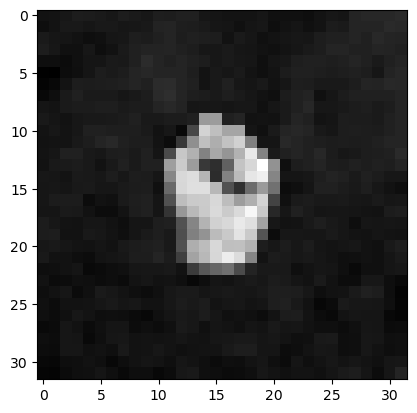

In [90]:
# train 의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

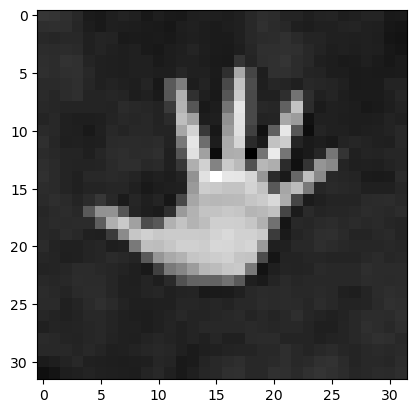

In [91]:
# test 의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

----
#### numpy 배열로 변경

In [92]:
import numpy as np

In [93]:
# train data 만들기. (18000 * 32 * 32) 이미지를 깡으로 numpy 배열에 넣을 순 없음. 변경해줘야 함.
tempData = np.zeros(
    18000 * 32 * 32,
    dtype=np.int32
).reshape(18000, 32, 32)
# tempData.shape

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img       # 18000 쪽에 하나씩 이미지 넣음
    i+=1

train_input = tempData.copy()

In [94]:
# test data 만들기. (3600 * 32 * 32) 이미지를 깡으로 numpy 배열에 넣을 순 없음. 변경해줘야 함.
tempData = np.zeros(
    3600 * 32 * 32,
    dtype=np.int32
).reshape(3600, 32, 32)

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img       # 18000 쪽에 하나씩 이미지 넣음
    i+=1

test_input = tempData.copy()

In [95]:
# 배열 크기 확인
print(train_input.shape, test_input.shape)

(18000, 32, 32) (3600, 32, 32)


In [96]:
train_input[0]      # 아깐 이미지였는데 이제 숫자로 변환된 모습

array([[51, 52, 55, ..., 66, 66, 68],
       [48, 52, 56, ..., 64, 68, 67],
       [57, 54, 53, ..., 67, 65, 63],
       ...,
       [47, 46, 54, ..., 51, 48, 50],
       [44, 43, 48, ..., 50, 54, 55],
       [42, 41, 46, ..., 47, 54, 64]], shape=(32, 32), dtype=int32)

----
#### Target 을 숫자로 변경하기

In [ ]:
label_to_int = {        # Target 은 이렇게 써도 됨
    '0R' : 0,
    "1R" : 1,
    "2R" : 2,
    "3R" : 3,
    "4R" : 4,
    "5R" : 5,
    "0L" : 6,
    "1L" : 7,
    "2L" : 8,
    "3L" : 9,
    "4L" : 10,
    "5L" : 11
}

In [98]:
# Train target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [99]:
# Test target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [100]:
train_target[:5]

[6, 6, 8, 6, 11]

In [101]:
test_target[:5]     # 현재 train_input 이 numpy로 되어있고 얜 list 라 인식 못함 그래서 동일하게 맞춰줘야 함.

[11, 11, 3, 11, 11]

In [102]:
# Target 도 numpy 배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

In [103]:
train_target[:5]

array([ 6,  6,  8,  6, 11])

In [104]:
test_target[:5]

array([11, 11,  3, 11, 11])

> 현재 train_input, train_target, test_input, test_target 분할하고 numpy 배열로 변경한 상태.

In [105]:
print(train_input.shape, train_target.shape)

(18000, 32, 32) (18000,)


In [106]:
# train 과 valid data 분리
from sklearn.model_selection import train_test_split

train_scaled = (train_input / 255.0).reshape(-1, 32*32)     # 정규화 + 2차
test_scaled = (test_input / 255.0).reshape(-1, 32*32)

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [107]:
from tensorflow import keras

In [108]:
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape = (1024, ), name='hidden'))
model.add(keras.layers.Dense(12, activation='softmax', name='output'))

In [109]:
print(train_scaled.shape, train_target.shape)

(14400, 1024) (14400,)


In [110]:
# 손실함수
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7705 - loss: 1.1651
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9453 - loss: 0.2810
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9721 - loss: 0.1296
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9862 - loss: 0.0734
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9915 - loss: 0.0458


In [111]:
print("train : ", model.evaluate(train_scaled, train_target)[1])
print("val : ", model.evaluate(val_scaled, val_target)[1])
print("test : ", model.evaluate(test_scaled, test_target)[1])

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9944 - loss: 0.0311
train :  0.9944444298744202
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9925 - loss: 0.0360
val :  0.9925000071525574
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9911 - loss: 0.0378
test :  0.9911110997200012


In [116]:
# 반복문 만들어봄
epoch_list = [5, 6, 7]
score = []

for epoch in epoch_list:
    model = keras.Sequential()
    model.add(keras.layers.Dense(100, activation='sigmoid', input_shape = (1024, ), name='hidden'))
    model.add(keras.layers.Dense(12, activation='softmax', name='output'))

    # 손실함수
    model.compile(
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
    )

    # 모델 훈련
    model.fit(train_scaled, train_target, epochs=epoch)

    # 검증 데이터로 확인
    total_score = print(epoch, "\n", 
                        "train : ", model.evaluate(train_scaled, train_target)[1],
                        "val : ", model.evaluate(val_scaled, val_target)[1],
                        "test : ", model.evaluate(test_scaled, test_target)[1])
    score.append(total_score)


Epoch 1/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7824 - loss: 1.1098
Epoch 2/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9492 - loss: 0.2672
Epoch 3/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9749 - loss: 0.1220
Epoch 4/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9867 - loss: 0.0699
Epoch 5/5
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9908 - loss: 0.0444
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step - accuracy: 0.9949 - loss: 0.0348
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9928 - loss: 0.0388
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9917 - loss: 0.0392
5 
 train :  0.9948611259460449 val :  0.9927777647972107 test :  0.9916666746139526
Epoch 1/6
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7718 - loss: 1.1435
Epoch 2/6
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9478 - loss: 0.2758
Epoch 3/6
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9742 - loss: 0.1275
Epoch 4/

2 
 train :  0.9676389098167419 val :  0.9636111259460449 test :  0.9663888812065125

 3 
 train :  0.9827083349227905 val :  0.9808333516120911 test :  0.9819444417953491

 4 
 train :  0.9874305725097656 val :  0.9863888621330261 test :  0.9855555295944214

 5 
 train :  0.9948611259460449 val :  0.9927777647972107 test :  0.9916666746139526   > 좋은듯? 은닉층 여러 개 만들어보고 결과값 보면 좋음

 6 
 train :  0.9847221970558167 val :  0.9816666841506958 test :  0.9788888692855835

 7 
 train :  0.9963194727897644 val :  0.9950000047683716 test :  0.9944444298744202

In [117]:
model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │       102,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,426 (810.26 KB)

 Trainable params: 103,712 (405.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 103,714 (405.14 KB)

In [118]:
pred = model.predict(test_scaled)
print("test label", test_target[:10])
print("pred max", np.argmax(pred[:10], axis=1))     # argmax : 예측값 중 최대값의 index

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step
test label [11 11  3 11 11  4  2  4 11  4]
pred max [11 11  3 11 11  4  2  4 11  4]


In [120]:
# test_data 의 0번 예측값을 확인
print("예측값 : ", np.argmax(pred[0]))

int_to_label = {v: k for k, v in label_to_int.items()}
print(int_to_label[np.argmax(pred[0])])

예측값 :  11
5L


여긴 그냥 해봄

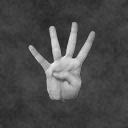

In [121]:
# Image 불러오기
img = Image.open("../Data/fingers/fingers/test/0062b79f-8fa4-4bbe-835c-a4811596bc84_4R.png")  # 아무거나 불러옴
img

In [137]:
# train 의 이미지 확인
train_input[50]

array([[57, 51, 47, ..., 60, 61, 61],
       [50, 53, 50, ..., 57, 61, 61],
       [46, 49, 51, ..., 54, 60, 62],
       ...,
       [59, 60, 55, ..., 50, 49, 51],
       [58, 62, 56, ..., 49, 47, 46],
       [59, 63, 56, ..., 49, 41, 36]], shape=(32, 32), dtype=int32)

In [138]:
train_target[50]        # << 이렇게 나오는 게 목표

np.int64(7)

In [139]:
train_input[50].shape

(32, 32)

In [140]:
# Image 를 numpy 배열로 변경하고 정규화 하기
imgArray = np.array(img)    / 255.0
imgArray.shape

(128, 128)

In [141]:
# image 를 1차원 배열로 변경
imgArray1 = imgArray.reshape(-1)
imgArray1.shape

(16384,)

In [142]:
imgArray2 = imgArray1.tolist()
imgArray2

[0.21568627450980393,
 0.21568627450980393,
 0.2235294117647059,
 0.23137254901960785,
 0.24313725490196078,
 0.23529411764705882,
 0.21176470588235294,
 0.20392156862745098,
 0.21568627450980393,
 0.22745098039215686,
 0.23921568627450981,
 0.23921568627450981,
 0.23137254901960785,
 0.22745098039215686,
 0.23137254901960785,
 0.2235294117647059,
 0.21568627450980393,
 0.21568627450980393,
 0.23137254901960785,
 0.22745098039215686,
 0.20392156862745098,
 0.19607843137254902,
 0.20392156862745098,
 0.20784313725490197,
 0.20784313725490197,
 0.21176470588235294,
 0.2196078431372549,
 0.2196078431372549,
 0.21176470588235294,
 0.2,
 0.18823529411764706,
 0.1843137254901961,
 0.1843137254901961,
 0.1843137254901961,
 0.1803921568627451,
 0.1843137254901961,
 0.19607843137254902,
 0.20784313725490197,
 0.21568627450980393,
 0.21176470588235294,
 0.19215686274509805,
 0.1843137254901961,
 0.1843137254901961,
 0.1803921568627451,
 0.1843137254901961,
 0.17647058823529413,
 0.15686274509803

In [143]:
import pandas as pd
dfArray = pd.DataFrame(imgArray2)
dfArray = dfArray.T         # 이전에 fit(학습)과 행 / 열 이 반대이기 때문에 이를 바꿔주기 위해 '.T' 로 바꿔줌
dfArray

,0,1,2,3,4,5,6,7,8,9,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,0.215686,0.215686,0.223529,0.231373,0.243137,0.235294,0.211765,0.203922,0.215686,0.227451,...,0.243137,0.239216,0.239216,0.235294,0.227451,0.219608,0.215686,0.211765,0.2,0.192157


In [144]:
print("예측값 : ", np.argmax(model.predict(dfArray), axis=1))

InvalidArgumentError: Graph execution error:

Detected at node sequential_30_1/hidden_1/Sigmoid defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\tjoeun\anaconda3\Lib\asyncio\base_events.py", line 683, in run_forever

  File "c:\Users\tjoeun\anaconda3\Lib\asyncio\base_events.py", line 2050, in _run_once

  File "c:\Users\tjoeun\anaconda3\Lib\asyncio\events.py", line 89, in _run

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\ipykernel\kernelbase.py", line 519, in dis

In [145]:
# 확률 확인
model.predict(dfArray)

InvalidArgumentError: Graph execution error:

Detected at node sequential_30_1/hidden_1/Sigmoid defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\tjoeun\anaconda3\Lib\asyncio\base_events.py", line 683, in run_forever

  File "c:\Users\tjoeun\anaconda3\Lib\asyncio\base_events.py", line 2050, in _run_once

  File "c:\Users\tjoeun\anaconda3\Lib\asyncio\events.py", line 89, in _run

  File "c:\Users\tjoeun\anaconda3\Lib\site-packages\ipykernel\kernelbase.py", line 519, in dis